In [1]:
import os

from fastai.vision.all import *
from fastai.vision.widgets import *

In [2]:
path = Path('/kaggle/input/datasets/hayder17/breast-cancer-detection/')
print(path)

/kaggle/input/datasets/hayder17/breast-cancer-detection


## Check and correct class in mammograph dataset

In [3]:
from collections import Counter

label = {'0': 'bình thường', '1': 'khối u'}
def get_label(file_path):
    folder_name = parent_label(file_path)
    return label.get(folder_name, "Unknown")

# counts number of normal and cancer breast's images
labels_all = [get_label(f) for f in get_image_files(path)]
print(f"số lượng mỗi label {Counter(labels_all)}")

số lượng mỗi label Counter({'bình thường': 2225, 'khối u': 1158})


## Add DataBlock with data augmentation and train with small batch size (16)
Create a DataBlock for mammograph images including appropriate transformations (resize, normalization, augmentation such as flipping/rotation).
Train the model using a small batch size (e.g., 16) to improve generalization.

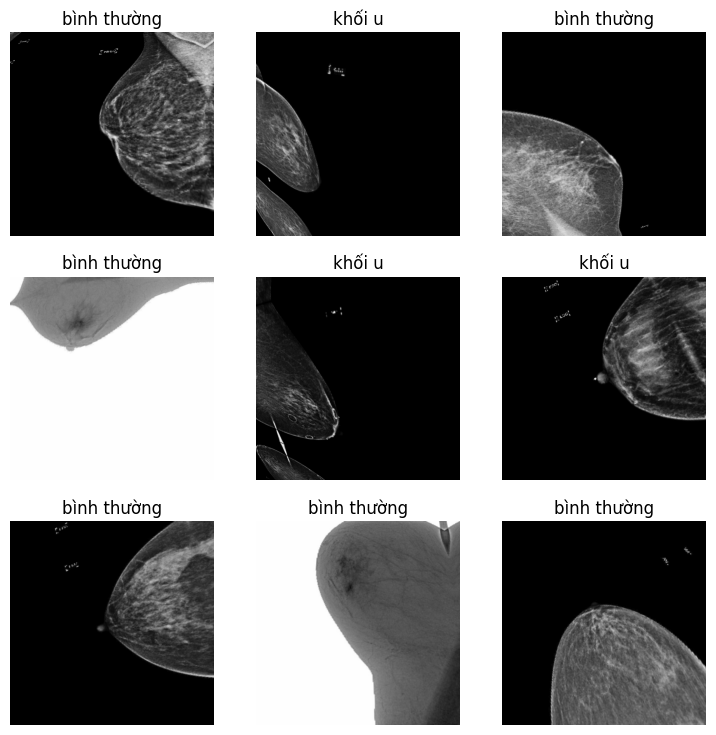

In [4]:
set_seed(42)
dbl = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    splitter=GrandparentSplitter(),
    get_items=get_image_files,
    get_y = get_label,
    item_tfms=Resize(512, method=ResizeMethod.Pad),
    batch_tfms=[
        *aug_transforms(mult=2, do_flip=True, flip_vert=True,
                      max_rotate=13.0, min_zoom=0.90, max_zoom=1.1),
        Normalize.from_stats(*imagenet_stats),
    ]
)
dls = dbl.dataloaders(path)
dls.show_batch(max_n=9, figsize=(9, 9))

## Set up learners with focus on reducing False Negatives in mammograph detection

In this task, missing a tumor (False Negative) is critical. Therefore, configure the learner to prioritize recall for tumor cases.

Define custom loss weights to penalize misclassification of tumor images more heavily than normal cases.

In [5]:
from fastai.losses import CrossEntropyLossFlat

weights = tensor([1.0, 3.0]).to(dls.device)
learner = vision_learner(dls,
                         resnet34,
                         loss_func=CrossEntropyLossFlat(weight=weights),
                         metrics=[error_rate, Recall(pos_label=1)])
learner.to_fp16()

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 200MB/s]


## Find optimal learning rate

Use learning rate finder to determine the most suitable learning rate for training the mammograph classification model.

<div></div>

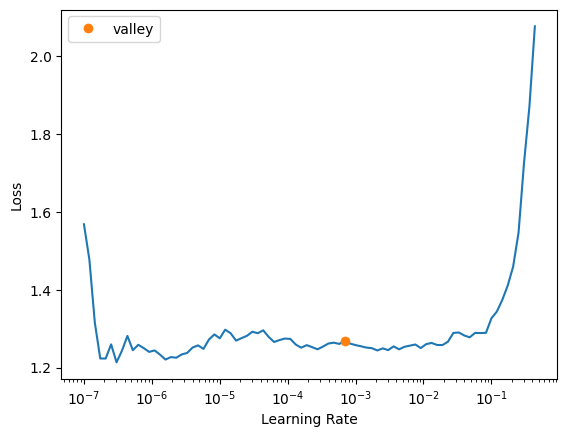

In [6]:
lr = learner.lr_find(suggest_funcs=(valley))

## Configure callbacks to monitor recall for tumor detection

Set up callbacks to monitor recall score during training, ensuring the model improves its ability to correctly detect tumors in mammograph images.

In [7]:
from fastai.callback.tracker import SaveModelCallback, EarlyStoppingCallback
cbs = [
    SaveModelCallback(
        monitor="recall_score",
        fname="best_model"
    ),
    SaveModelCallback(
        monitor="error_rate",
        fname="best_acc_model"
    ),
    EarlyStoppingCallback(
        monitor="recall_score",
        patience=7
    )
]

## Train the model with frozen layers, then fine-tune

First, train the model with frozen backbone layers for 3 epochs.
Then unfreeze the model and fine-tune to improve performance on mammograph data.

In [8]:
learner.fine_tune(20, 
                  base_lr=lr.valley,
                  freeze_epochs=3,
                  cbs=cbs)

epoch,train_loss,valid_loss,error_rate,recall_score,time
0,1.273114,0.763547,0.416296,0.286344,00:29
1,1.208441,0.971139,0.514074,0.656388,00:29
2,1.113893,1.069848,0.509630,0.775330,00:30


Better model found at epoch 0 with recall_score value: 0.28634361233480177.
Better model found at epoch 0 with error_rate value: 0.4162963032722473.
Better model found at epoch 1 with recall_score value: 0.6563876651982379.
Better model found at epoch 2 with recall_score value: 0.775330396475771.


epoch,train_loss,valid_loss,error_rate,recall_score,time
0,1.240187,0.847807,0.496296,0.546256,00:35
1,1.162099,0.887576,0.525926,0.713656,00:36
2,1.141715,0.879419,0.500741,0.700441,00:35
3,1.124048,0.850720,0.488889,0.643172,00:35
4,1.087420,0.973172,0.512593,0.801762,00:36
5,1.050884,0.904229,0.531852,0.766520,00:35
6,1.001976,1.038872,0.515556,0.797357,00:36
7,0.966727,1.034658,0.554074,0.854626,00:35
8,0.939587,0.936773,0.542222,0.845815,00:35
9,0.923723,0.932206,0.539259,0.885463,00:35


Better model found at epoch 0 with recall_score value: 0.5462555066079295.
Better model found at epoch 0 with error_rate value: 0.4962962865829468.
Better model found at epoch 1 with recall_score value: 0.7136563876651982.
Better model found at epoch 3 with error_rate value: 0.4888888895511627.
Better model found at epoch 4 with recall_score value: 0.801762114537445.
Better model found at epoch 7 with recall_score value: 0.8546255506607929.
Better model found at epoch 9 with recall_score value: 0.8854625550660793.
Better model found at epoch 10 with recall_score value: 0.9295154185022027.
Better model found at epoch 13 with error_rate value: 0.4725925922393799.
No improvement since epoch 10: early stopping


## Evaluate model: False Negatives and False Positives

Analyze model predictions:
- False Negatives: tumor images predicted as normal (critical error)
- False Positives: normal images predicted as tumor

Ensure the model minimizes False Negatives

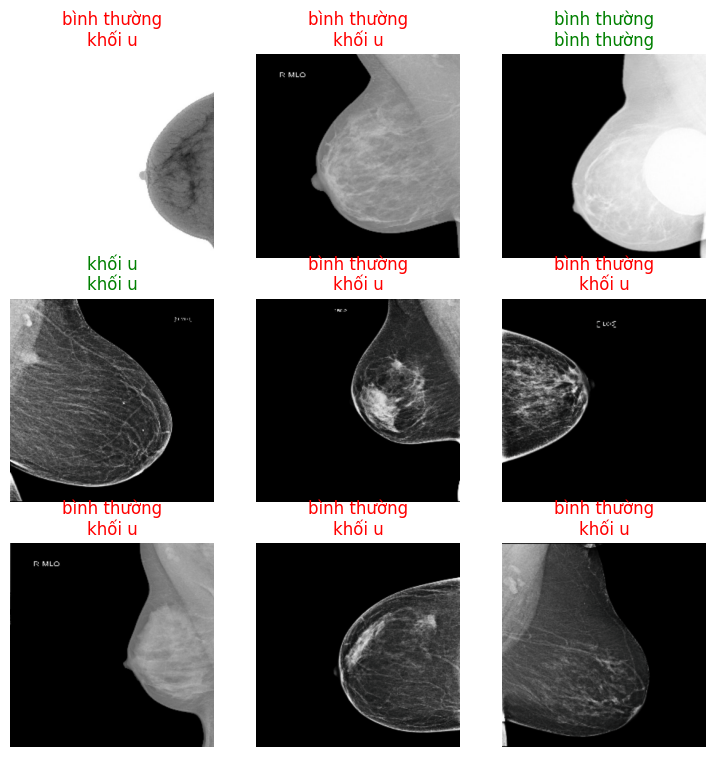

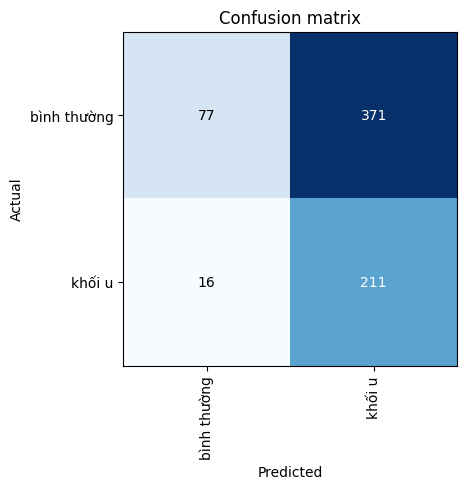

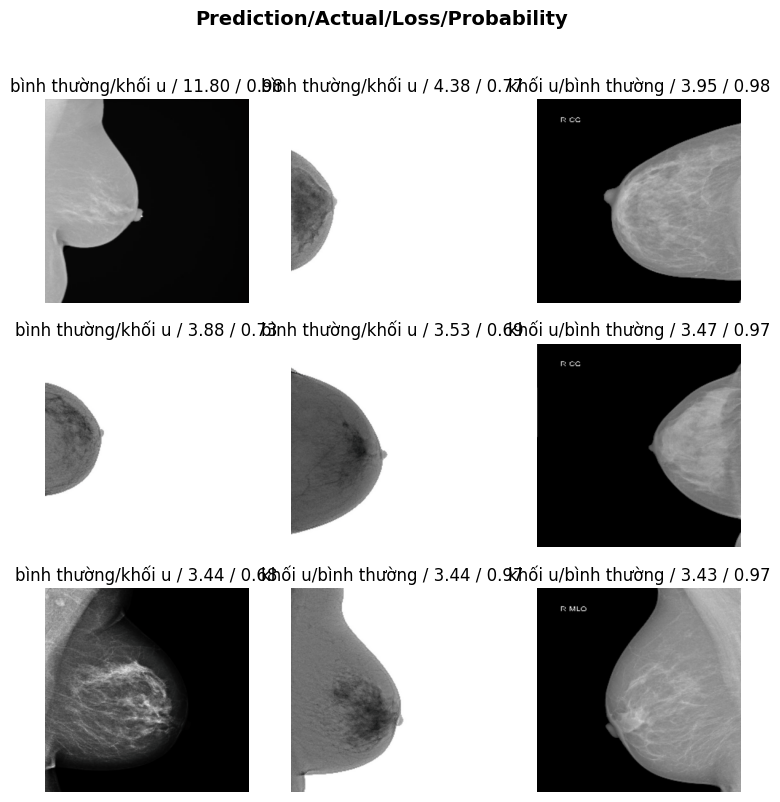

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Take the best recall model
learner.load('best_model', with_opt=False)
#Do test
learner.show_results()
interp = ClassificationInterpretation.from_learner(learner)
interp.plot_confusion_matrix()
interp.plot_top_losses(9)

In [10]:
learner.export('model.pkl')
!find /kaggle/working -name "model.pkl"

/kaggle/working/model.pkl


## Code to upload image

Provide code to upload and load mammograph image data into the training pipeline.

In [11]:
import ipywidgets as widgets

uploader = widgets.FileUpload(accept='image/*', multiple=False)
display(uploader)

FileUpload(value=(), accept='image/*', description='Upload')

In [12]:
img_bytes = uploader.value[0]['content'].tobytes()
img = PILImage.create(io.BytesIO(img_bytes))

is_cancer, _, probs = learner.predict(img)
print(f"Is this a cancer breast?: {is_cancer}.")
print(f"Probability it's a cancer breast: {probs[1].item():.6f}")

IndexError: tuple index out of range